In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

c:\Users\nasta\anaconda3\envs\ssp_metamodel_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [4]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v5.5.csv") #NOTE: update filename as needed
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_frac_fgtv_reduction_in_fugitive_leaks,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
0,0.073998,0.692822,0.979482,0.051058,0.188261,0.581816,0.698145,0.216501,0.371199,0.101867,...,0.792661,0.700647,134.250713,4713.726381,279.612528,4.567414e+08,-2.275659,1.033437,7184.221916,69844.538790
1,0.425023,0.729207,0.384489,0.436918,0.621826,0.168596,0.725935,0.167295,0.723122,0.186405,...,0.031865,0.682710,164.387644,5168.255434,276.395578,4.708078e+08,-7.468213,0.753391,10553.138793,114591.865227
2,0.881846,0.761554,0.325130,0.205597,0.237030,0.682775,0.718216,0.452701,0.761919,0.602002,...,0.578509,0.348348,104.151002,4411.805579,264.412432,4.615890e+08,-3.833560,1.181780,10329.819880,61421.909034
3,0.075106,0.542313,0.668099,0.577434,0.767079,0.804253,0.966784,0.248884,0.082841,0.381400,...,0.536350,0.855946,157.680453,5094.995066,275.458617,4.799190e+08,-10.618699,0.727183,27913.284914,240984.764590
4,0.057338,0.477879,0.866591,0.161689,0.282495,0.282664,0.310182,0.991945,0.953932,0.864061,...,0.048358,0.042901,187.314145,5488.927406,243.699542,4.032488e+08,-6.069652,0.963409,8311.856268,132260.785244


## EDA

In [5]:
edau = EDAUtils()

In [6]:
target_cols = [col for col in training_df.columns if not(col.startswith("group_"))]
target_cols

['emission_avg_last_five_years',
 'emission_total',
 'production_total',
 'production_cost_total',
 'technical_cost',
 'air_pollution',
 'num_jobs',
 'earning_per_job']

In [7]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
lhs_group_cols

['group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha',
 'group_2_frac_agrc_agriculture_production_lost',
 'group_3_frac_agrc',
 'group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture',
 'group_5_nemomod_entc_frac_min_share_production_fp_hydrogen',
 'group_6_nemomod_en',
 'group_7_frac_fgtv_reduction_in_fugitive_leaks',
 'group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel',
 'group_9_efficfactor_enfu_industrial_energy_fuel',
 'group_10_scalar_inen_energy_demand',
 'group_11_frac_inen_energy',
 'group_12_frac_ippu_cement_clinker',
 'group_13_ef_ippu_tonne_c',
 'group_14_ef_ippu_tonne_n2o_per',
 'group_15_ef_ippu_tonne_c',
 'group_16_pij_lndu',
 'group_17_frac_lndu_improved_pastures',
 'group_18_lndu_reallocation_factor',
 'group_19_gasrf_lsmm_biogas_anaerobic',
 'group_20_frac_lvst_mm',
 'group_21_frac_lvst_mm',
 'group_22_frac_lvst_mm_chickens',
 'group_23_ef_lvst_entferm',
 'group_24_frac_gnrl_eating_red_meat',
 'group_25_frac_ippu_production_with_co2_capture',
 'group_26_scalar

In [8]:
training_df[target_cols].describe()

,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
count,963.000000,963.000000,963.000000,9.630000e+02,963.000000,963.000000,963.000000,9.630000e+02
mean,144.973345,4932.173035,268.159983,4.622502e+08,-5.870342,0.705426,15999.255775,9.851523e+04
std,29.413401,403.776245,14.000823,3.275217e+07,1.979261,0.292490,7160.346491,2.909008e+05
min,-10.475430,1146.940292,236.313867,3.865603e+08,-13.593731,-0.180472,-935.000991,-2.135233e+06
25%,125.338062,4680.694686,257.389525,4.393551e+08,-7.096128,0.500925,10942.515865,6.600349e+04
50%,144.215331,4912.475266,267.899303,4.592315e+08,-5.833292,0.722634,15650.704923,7.956016e+04
75%,164.749486,5199.946870,278.829352,4.845767e+08,-4.563625,0.913443,20987.798851,9.427431e+04
max,230.334810,6033.346162,305.232276,5.536810e+08,9.141555,1.506948,57953.962159,5.845547e+06


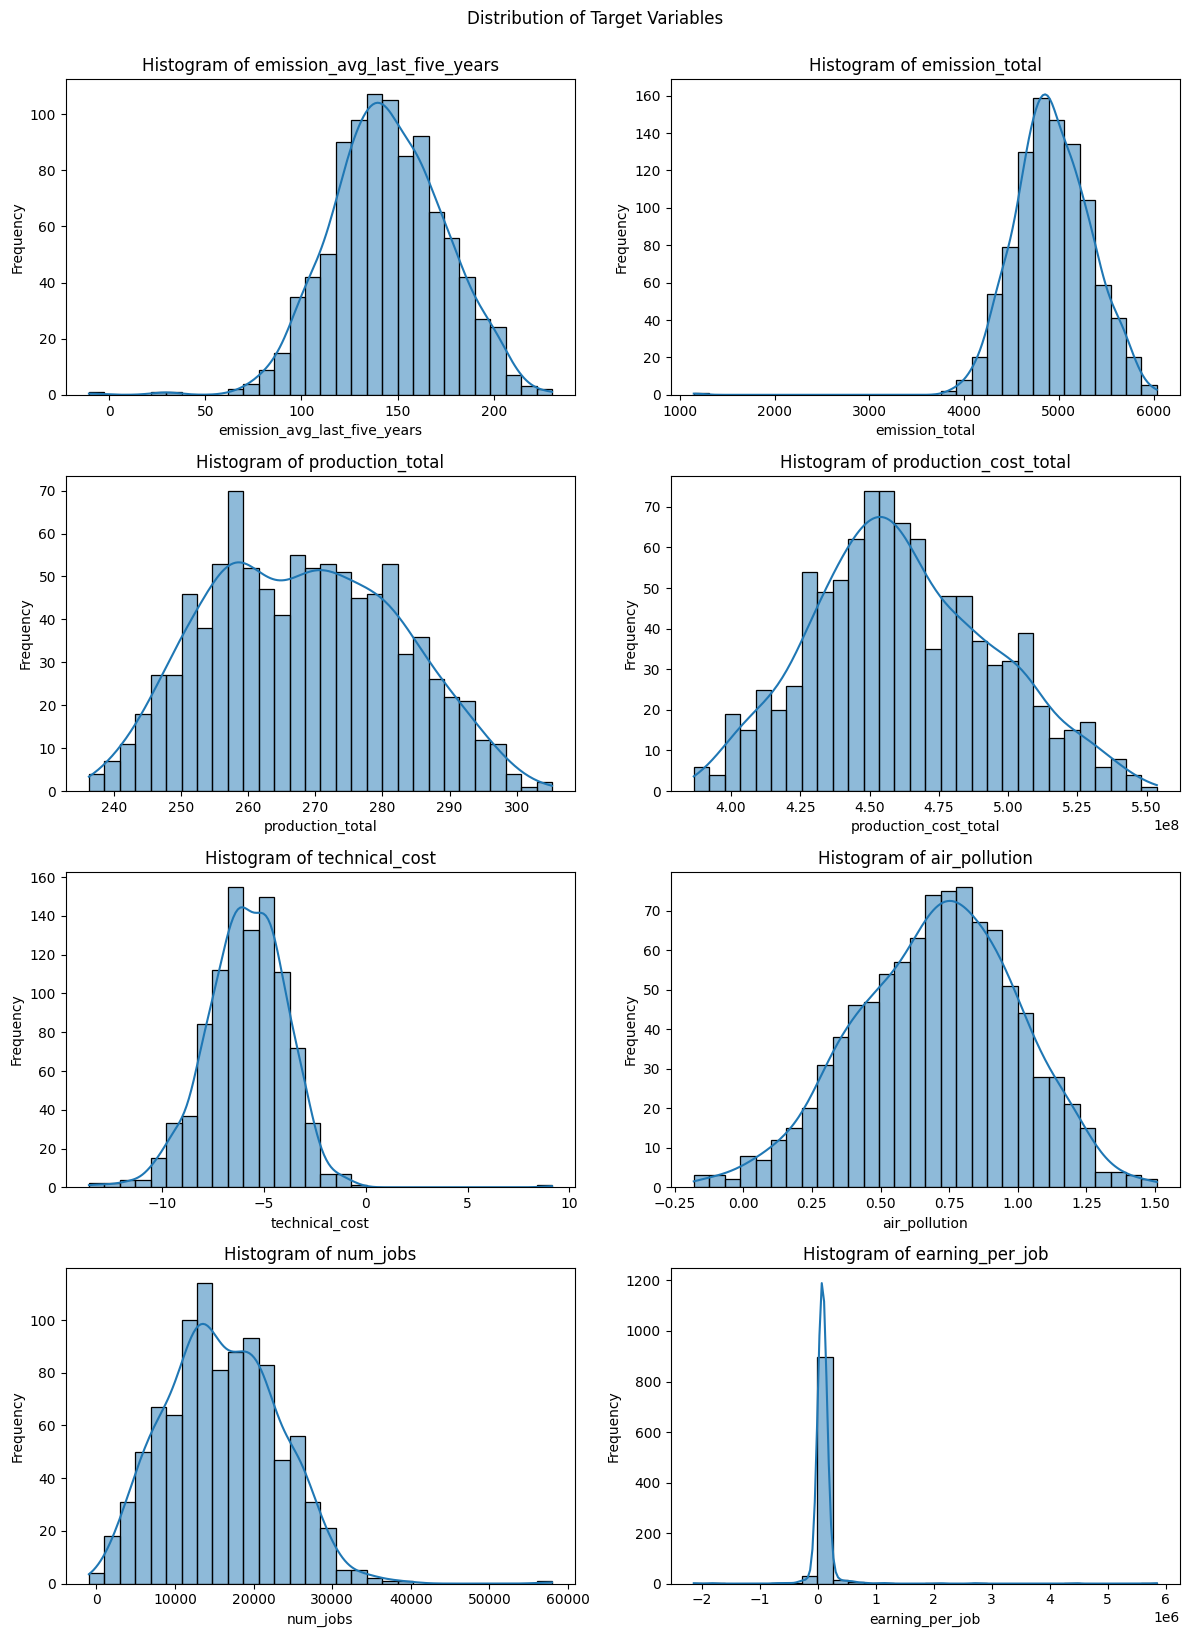

In [9]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")

In [10]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "num_jobs", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "earning_per_job", exclude_cols=target_cols)
	


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
group_6_nemomod_en             : 0.6403
group_51_exports_enfu_pj_fuel  : 0.5481
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2244
group_7_frac_fgtv_reduction_in_fugitive_leaks : 0.1750
group_11_frac_inen_energy      : 0.1455
group_57_elasticity_ippu       : 0.1346
group_56_elasticity_trde_pkm_to_gdppc : 0.1112
group_31_demscalar_trde        : 0.1105
group_52_gdp_mmm_usd           : 0.1076


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
group_6_nemomod_en             : 0.6550
group_51_exports_enfu_pj_fuel  : 0.5507
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2398
group_7_frac_fgtv_reduction_in_fugitive_leaks : 0.1959
group_57_elasticity_ippu       : 0.1554
group_56_elasticity_trde_pkm_to_gdppc : 0.1423
group_31_demscalar_trde      

In [ ]:
# Find constant / near-constant cols
# const_cols = edau.find_constant_columns(training_df)
# near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
# print("Constant:", const_cols)
# print("Near-constant:", near_const_cols)

In [11]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_avg_last_five_years': 0.52, 'emission_total': 0.52, 'production_cost_total': 0.1, 'technical_cost': 1.14, 'air_pollution': 0.31, 'num_jobs': 0.42, 'earning_per_job': 15.58}


## Data Cleaning

In [12]:
dcu = DataCleaningUtils()

In [13]:
training_df.shape

(963, 66)

In [ ]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [ ]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [14]:

training_df_cleaned = dcu.remove_outliers(training_df, method="iqr", factor=1.5)
print("Shape before removing outliers:", training_df.shape)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape before removing outliers: (963, 66)
Shape after removing outliers: (797, 66)


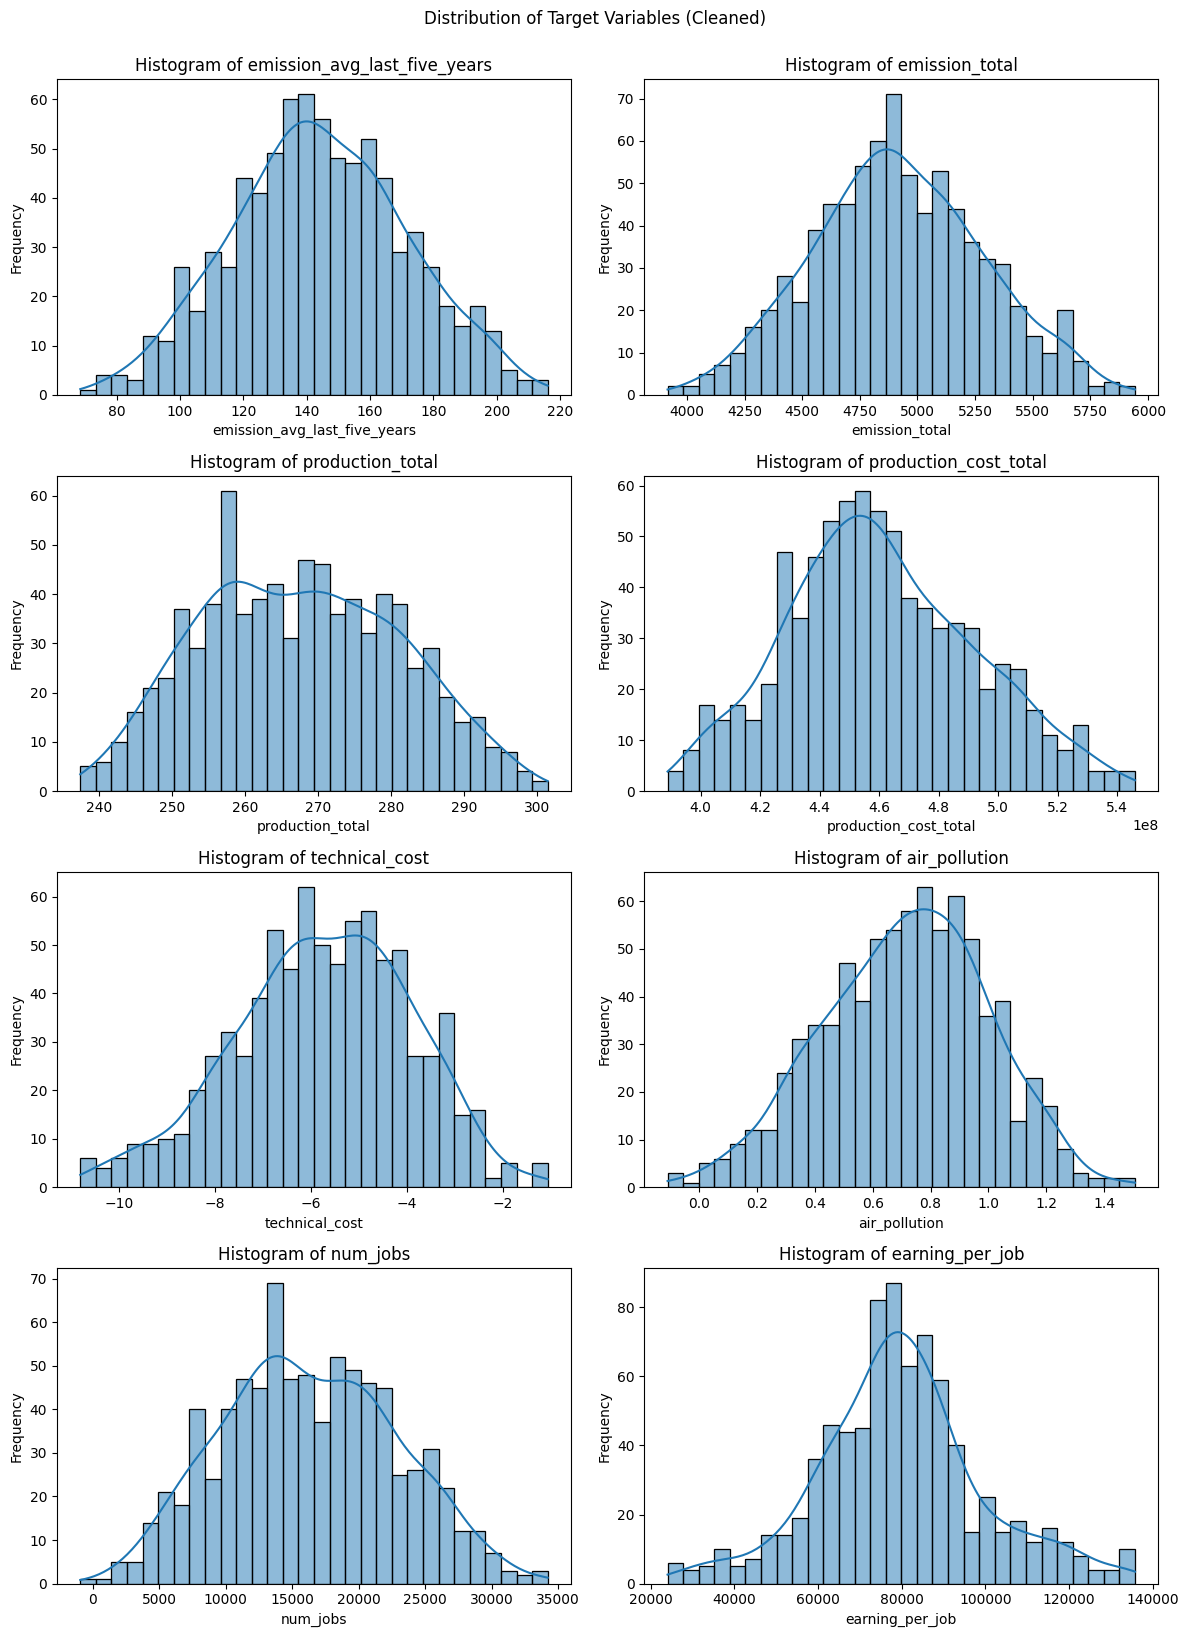

In [15]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [16]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {}


In [17]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "num_jobs", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "earning_per_job", exclude_cols=target_cols)


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
group_6_nemomod_en             : 0.6403
group_51_exports_enfu_pj_fuel  : 0.5481
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2244
group_7_frac_fgtv_reduction_in_fugitive_leaks : 0.1750
group_11_frac_inen_energy      : 0.1455
group_57_elasticity_ippu       : 0.1346
group_56_elasticity_trde_pkm_to_gdppc : 0.1112
group_31_demscalar_trde        : 0.1105
group_52_gdp_mmm_usd           : 0.1076


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
group_6_nemomod_en             : 0.6550
group_51_exports_enfu_pj_fuel  : 0.5507
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2398
group_7_frac_fgtv_reduction_in_fugitive_leaks : 0.1959
group_57_elasticity_ippu       : 0.1554
group_56_elasticity_trde_pkm_to_gdppc : 0.1423
group_31_demscalar_trde      

In [18]:
training_df_cleaned[target_cols].describe()

,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
count,797.000000,797.000000,797.000000,7.970000e+02,797.000000,797.000000,797.000000,797.000000
mean,144.021560,4918.763989,267.548331,4.606236e+08,-5.744710,0.714186,16299.928780,79679.649826
std,27.414836,368.443547,13.590851,3.164592e+07,1.826422,0.282003,6537.327100,19883.200475
min,68.477202,3916.183111,237.375905,3.889148e+08,-10.806834,-0.109246,-935.000991,24077.902696
25%,125.178369,4670.780802,257.231516,4.387181e+08,-6.937113,0.516244,11650.989864,68110.199376
50%,143.453882,4905.444917,267.646755,4.577263e+08,-5.663146,0.731599,16001.436392,78728.376782
75%,162.266630,5161.324559,278.190871,4.818024e+08,-4.400920,0.912867,21013.695192,89426.129179
max,216.113864,5943.360990,301.505275,5.459978e+08,-1.069483,1.506948,34218.359739,135781.538646


In [ ]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [ ]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

### Individual Training

In [ ]:
# negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
# positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]


In [ ]:
# negative_epp = EmissionsPredictionPipeline(
#     df=negative_emissions_df,
#     target="total_negative_emissions",
#     test_size=0.2,
#     random_state=42,
# )

# negative_epp.run(tune=False, log_transform=False, create_plots=False)

In [ ]:
# positive_epp = EmissionsPredictionPipeline(
#     df=positive_emissions_df,
#     target="total_positive_emissions",
#     test_size=0.2,
#     random_state=42,
# )
# positive_epp.run(tune=False, log_transform=False, create_plots=False)

### Multi Output Training

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB hyperparameters: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.7}

=== XGB ===
emission_avg_last_five_years  
  Train → MAE: 1.1177, RMSE: 1.4233, R²: 0.9973, SMAPE: 0.8%
   Test → MAE: 5.8600, RMSE: 7.4426, R²: 0.9220, SMAPE: 4.3%
emission_total                
  Train → MAE: 13.7706, RMSE: 17.7698, R²: 0.9977, SMAPE: 0.3%
   Test → MAE: 77.2639, RMSE: 98.1232, R²: 0.9238, SMAPE: 1.6%
production_total              
  Train → MAE: 0.2552, RMSE: 0.3210, R²: 0.9994, SMAPE: 0.1%
   Test → MAE: 1.1489, RMSE: 1.4287, R²: 0.9888, SMAPE: 0.4%
production_cost_total         
  Train → MAE: 597364.5761, RMSE: 752281.3816, R²: 0.9994, SMAPE: 0.1%
   Test → MAE: 2530976.4069, RMSE: 3173600.3252, R²: 0.9902, SMAPE: 0.5%
technical_cost                
  Train → MAE: 0.1551, RMSE: 0.1976, R²: 0.9882, SMAPE: 3.0%
   Test → MAE: 0.6098, RMSE: 

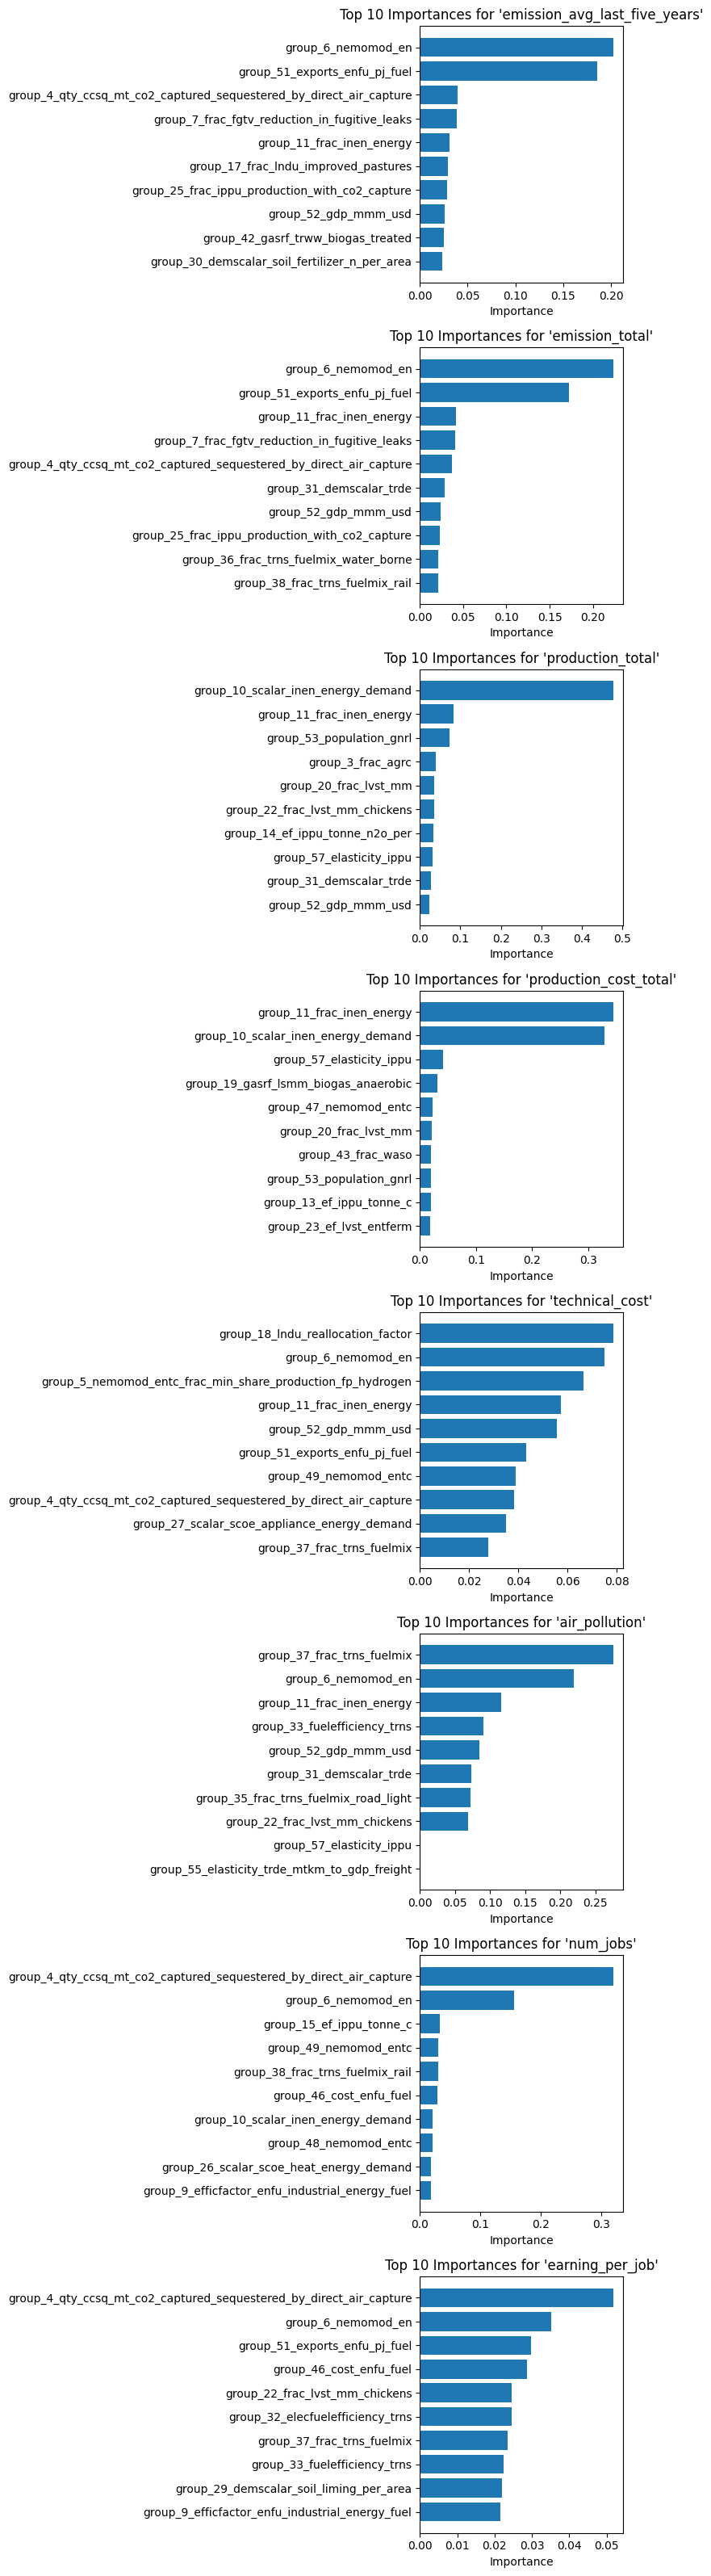

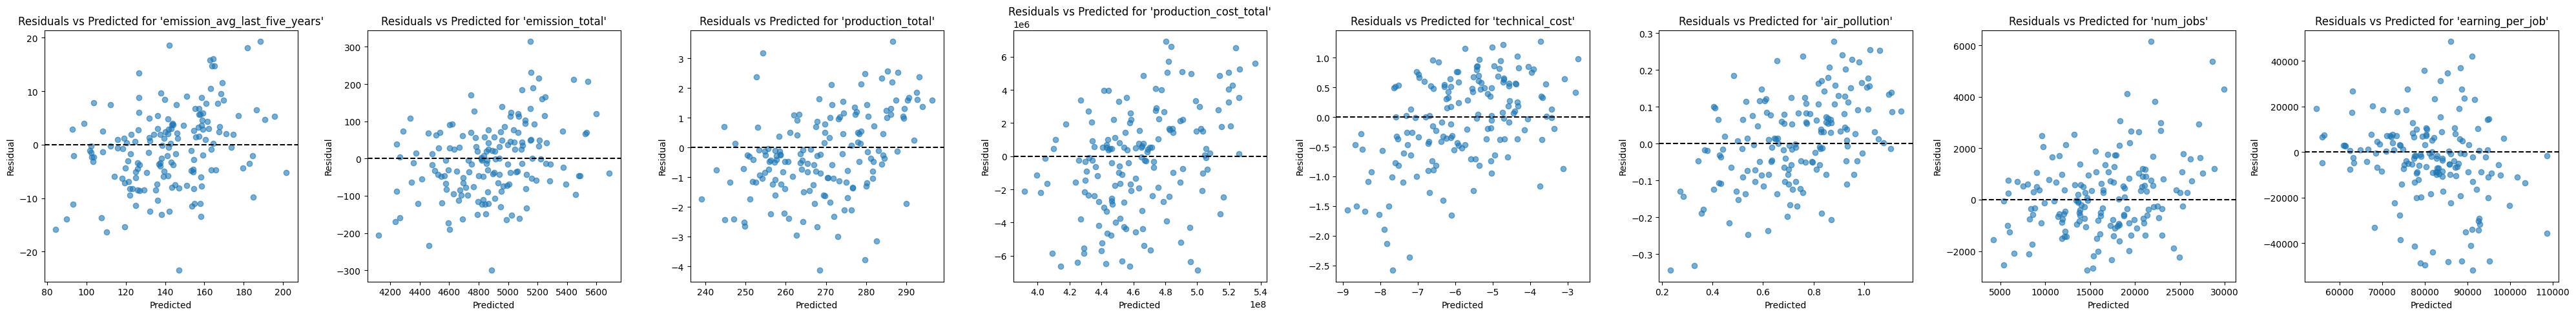

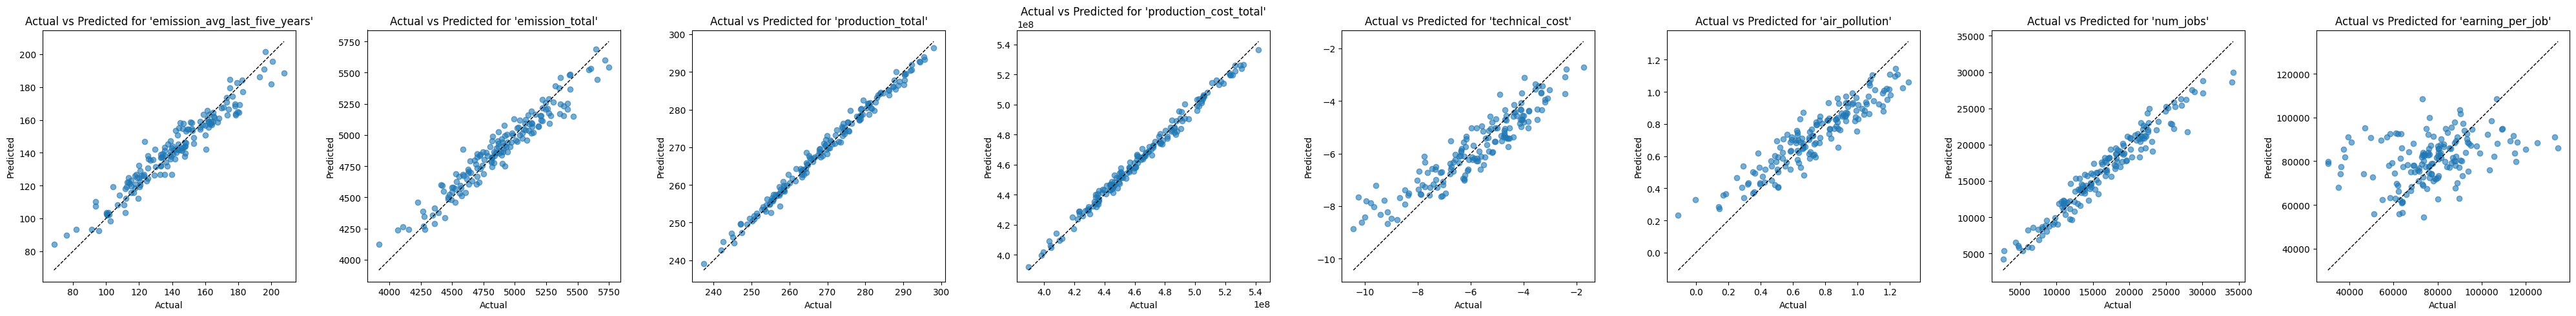

In [19]:
mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=target_cols)
mulp.run(tune=True, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [20]:
training_df_cleaned.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_frac_fgtv_reduction_in_fugitive_leaks,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
0,0.073998,0.692822,0.979482,0.051058,0.188261,0.581816,0.698145,0.216501,0.371199,0.101867,...,0.792661,0.700647,134.250713,4713.726381,279.612528,4.567414e+08,-2.275659,1.033437,7184.221916,69844.538790
1,0.425023,0.729207,0.384489,0.436918,0.621826,0.168596,0.725935,0.167295,0.723122,0.186405,...,0.031865,0.682710,164.387644,5168.255434,276.395578,4.708078e+08,-7.468213,0.753391,10553.138793,114591.865227
2,0.881846,0.761554,0.325130,0.205597,0.237030,0.682775,0.718216,0.452701,0.761919,0.602002,...,0.578509,0.348348,104.151002,4411.805579,264.412432,4.615890e+08,-3.833560,1.181780,10329.819880,61421.909034
4,0.057338,0.477879,0.866591,0.161689,0.282495,0.282664,0.310182,0.991945,0.953932,0.864061,...,0.048358,0.042901,187.314145,5488.927406,243.699542,4.032488e+08,-6.069652,0.963409,8311.856268,132260.785244
5,0.511133,0.698963,0.711505,0.683995,0.437127,0.227332,0.355119,0.640986,0.844816,0.833615,...,0.256756,0.677597,154.259184,5011.043324,250.400601,4.181826e+08,-4.700765,0.677055,11844.335272,88061.428521


In [21]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(target_cols)
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_frac_fgtv_reduction_in_fugitive_leaks,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_49_nemomod_entc,group_50_nemomod_enst_capital_cost_st,group_51_exports_enfu_pj_fuel,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use
0,0.073998,0.692822,0.979482,0.051058,0.188261,0.581816,0.698145,0.216501,0.371199,0.101867,...,0.653223,0.662849,0.115262,0.601828,0.954157,0.508737,0.781123,0.313322,0.792661,0.700647


In [22]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)
print("Original values:")
print(training_df_cleaned.iloc[0][target_cols])

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
0                    132.947678     4727.477539        279.481415   

   production_cost_total  technical_cost  air_pollution     num_jobs  \
0            456510592.0       -2.149045       0.907394  7174.820312   

   earning_per_job  
0     64290.136719  
Original values:
emission_avg_last_five_years    1.342507e+02
emission_total                  4.713726e+03
production_total                2.796125e+02
production_cost_total           4.567414e+08
technical_cost                 -2.275659e+00
air_pollution                   1.033437e+00
num_jobs                        7.184222e+03
earning_per_job                 6.984454e+04
Name: 0, dtype: float64


In [23]:
# Save the trained model
xgb_pipeline = mulp.pipelines["XGB"]
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.5.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)
overwrite_existing_model = True  # Set to True to overwrite existing model

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH) and not overwrite_existing_model:
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
else:
    print(f"Saving model {model_file_name} to {MODEL_PATH}.")
    joblib.dump(xgb_pipeline, MODEL_PATH)


Saving model xgb_pipeline_5.5.pkl to e:\Current_2023\WI\work\ssp_louisiana\metamodel\notebooks\trained_models\xgb_pipeline_5.5.pkl.


In [24]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [25]:
# Predict using the trained model
predictions = mulp.predict(single_row, ml_pipeline=xgb_pipeline_loaded)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
0                    132.947678     4727.477539        279.481415   

   production_cost_total  technical_cost  air_pollution     num_jobs  \
0            456510592.0       -2.149045       0.907394  7174.820312   

   earning_per_job  
0     64290.136719  


In [26]:
from pathlib import Path
TRAINED_MODELS_DIR = Path(TRAINED_MODELS_DIR)
mulp.X_test.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.5_x_test.parquet")
mulp.y_test.to_parquet(TRAINED_MODELS_DIR/"xgb_pipeline_5.5_y_test.parquet")


In [27]:
training_df_cleaned.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.5_training_df.parquet")

In [28]:
training_df_cleaned

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_frac_fgtv_reduction_in_fugitive_leaks,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
0,0.073998,0.692822,0.979482,0.051058,0.188261,0.581816,0.698145,0.216501,0.371199,0.101867,...,0.792661,0.700647,134.250713,4713.726381,279.612528,4.567414e+08,-2.275659,1.033437,7184.221916,69844.538790
1,0.425023,0.729207,0.384489,0.436918,0.621826,0.168596,0.725935,0.167295,0.723122,0.186405,...,0.031865,0.682710,164.387644,5168.255434,276.395578,4.708078e+08,-7.468213,0.753391,10553.138793,114591.865227
2,0.881846,0.761554,0.325130,0.205597,0.237030,0.682775,0.718216,0.452701,0.761919,0.602002,...,0.578509,0.348348,104.151002,4411.805579,264.412432,4.615890e+08,-3.833560,1.181780,10329.819880,61421.909034
4,0.057338,0.477879,0.866591,0.161689,0.282495,0.282664,0.310182,0.991945,0.953932,0.864061,...,0.048358,0.042901,187.314145,5488.927406,243.699542,4.032488e+08,-6.069652,0.963409,8311.856268,132260.785244
5,0.511133,0.698963,0.711505,0.683995,0.437127,0.227332,0.355119,0.640986,0.844816,0.833615,...,0.256756,0.677597,154.259184,5011.043324,250.400601,4.181826e+08,-4.700765,0.677055,11844.335272,88061.428521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,0.635142,0.603678,0.650826,0.938293,0.532791,0.458046,0.964056,0.549375,0.406465,0.937233,...,0.815408,0.150082,121.594420,4691.472707,248.818823,4.102299e+08,-4.849271,0.827842,20074.832845,91639.779457
959,0.523444,0.024740,0.631766,0.447112,0.909923,0.343413,0.604907,0.239868,0.477267,0.551167,...,0.710320,0.501973,162.146717,5202.036088,269.682673,4.655390e+08,-8.026771,0.250140,13488.129216,116293.548455
960,0.480615,0.560271,0.266827,0.643640,0.040585,0.020424,0.617931,0.743517,0.274302,0.251297,...,0.957187,0.471602,194.313061,5592.469537,292.994094,5.283043e+08,-5.954081,0.030116,16191.791192,78560.507381
961,0.083011,0.230503,0.294934,0.197481,0.891935,0.140418,0.135728,0.777188,0.748830,0.282061,...,0.979377,0.900547,200.981586,5717.910263,282.274217,4.902101e+08,-7.731554,0.563744,6795.072635,73039.006672
